In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# import os

# path = "/content/drive/MyDrive/pn"
# print(os.listdir(path))

In [4]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

In [5]:
labels = ['PNEUMONIA','NORMAL']
img_size = 128
def get_data(data_dir):
    images = []
    labels_list = []



    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))

                images.append(resized_arr)
                labels_list.append(class_num)

            except Exception as e:
                print(e)

    return np.array(images), np.array(labels_list)


In [6]:
train = get_data("chest_xray/chest_xray/train")
test = get_data("chest_xray/chest_xray/test")
val = get_data("chest_xray/chest_xray/val")

In [7]:
pneumonia = os.listdir("chest_xray/train/PNEUMONIA")
penomina_dir = "chest_xray/train/PNEUMONIA"

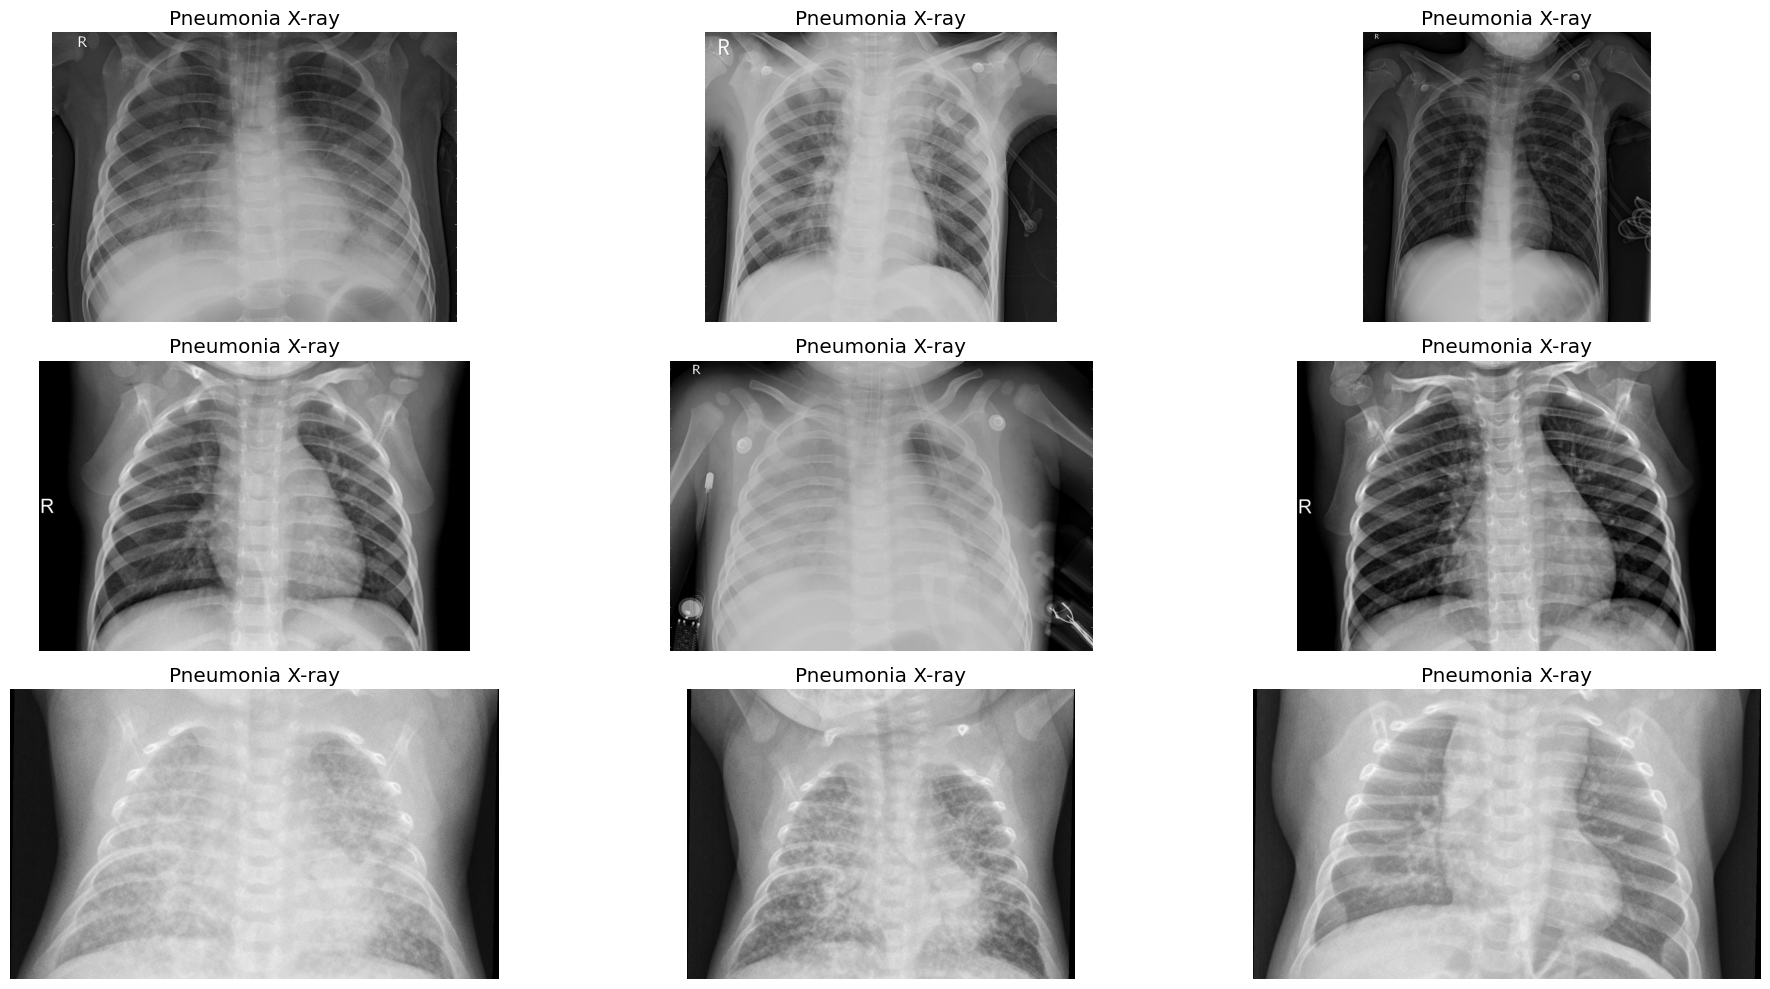

In [8]:
plt.figure(figsize=(20,10))

for i in range(9):
    plt.subplot(3,3, i+1)
    img = plt.imread(os.path.join(penomina_dir, pneumonia[i]))
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Pneumonia X-ray")
plt.tight_layout()

In [9]:
normal = os.listdir("chest_xray/train/NORMAL")
normal_dir = "chest_xray/train/NORMAL"

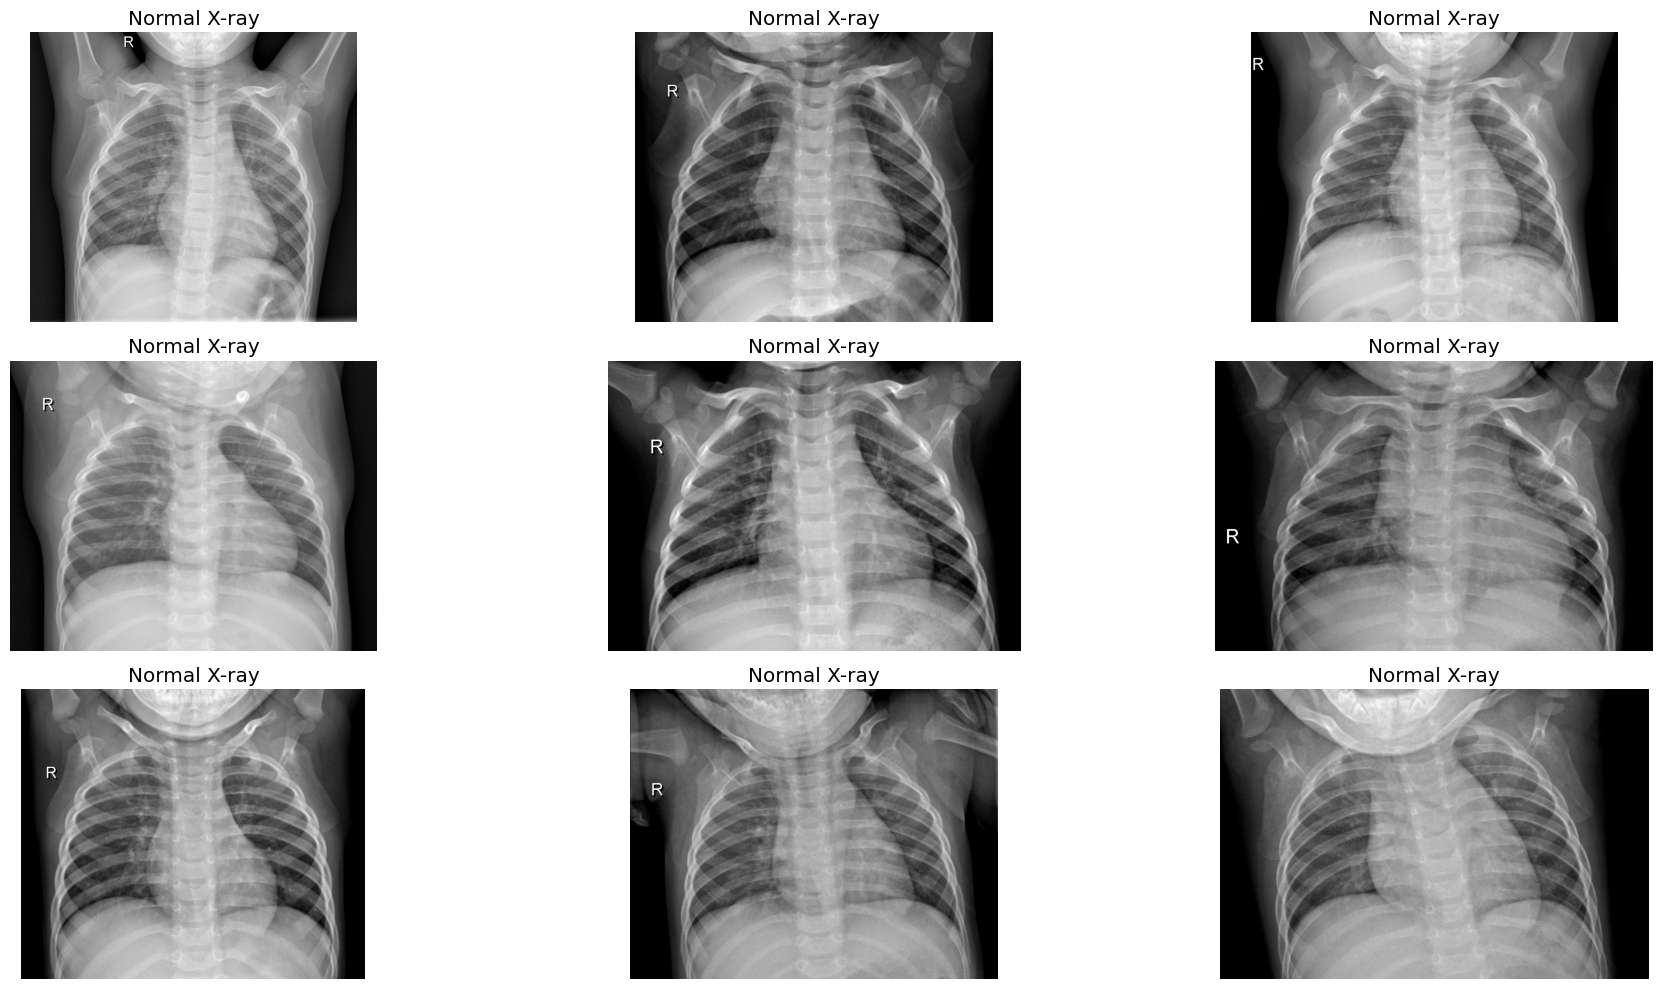

In [10]:
plt.figure(figsize=(20,10))

for i in range(9):
    plt.subplot(3,3, i+1)
    img = plt.imread(os.path.join(normal_dir, normal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Normal X-ray")
plt.tight_layout()

Pnumonia = 479
Normal =264


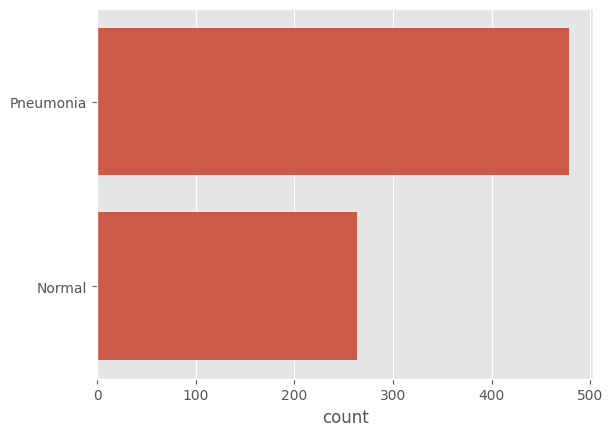

In [11]:
X_train, y_train = train  # image,label
pnumonia_cnt=0
normal_cnt=0

listx = []
for label in y_train:
    if label == 0:
        listx.append("Pneumonia")
        pnumonia_cnt+=1
    else:
        listx.append("Normal")
        normal_cnt+=1
sns.countplot(listx)
print(f'Pnumonia = {pnumonia_cnt}')
print(f'Normal ={normal_cnt}')


<Axes: xlabel='count'>

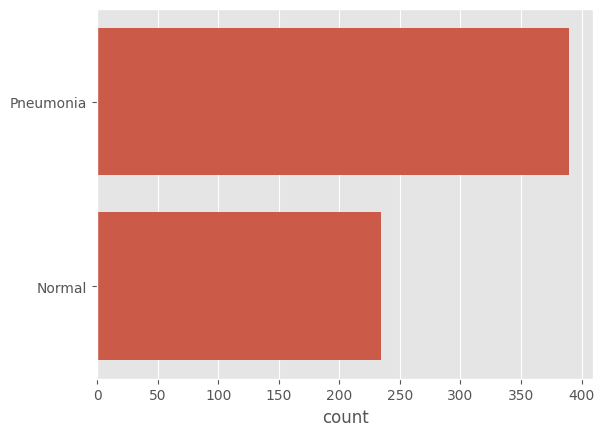

In [12]:
X_test, y_test = test  # image,label

listx = []
for label in y_test:
    if label == 0:
        listx.append("Pneumonia")
    else:
        listx.append("Normal")
sns.countplot(listx)

In [13]:
# Data Augmentation & Resizing

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D,Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [15]:
train_datagen = ImageDataGenerator(rescale = 1. / 255,
                  horizontal_flip=0.4,
                  vertical_flip=0.4,
                  rotation_range=40,
                  shear_range=0.2,
                  width_shift_range=0.4,
                  height_shift_range=0.4,
                  fill_mode="nearest")
valid_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [16]:
train_generator = train_datagen.flow_from_directory("chest_xray/chest_xray/train",
                                 batch_size = 32,
                                 target_size=(128,128),
                                 class_mode = 'categorical', #PNEUMONIA → [1,0] and NORMAL   → [0,1]
                                 shuffle=True,
                                 seed = 42,
                                 color_mode = 'rgb')
valid_generator = valid_datagen.flow_from_directory("chest_xray/chest_xray/val",
                                 batch_size = 32,
                                 target_size=(128,128),
                                 class_mode = 'categorical',
                                 shuffle=True,
                                 seed = 42,
                                 color_mode = 'rgb')

Found 743 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [17]:
class_labels = train_generator.class_indices

In [18]:
class_labels

{'NORMAL': 0, 'PNEUMONIA': 1}

In [19]:
class_name = {value:key for (key, value) in class_labels.items()}

In [20]:
class_name

{0: 'NORMAL', 1: 'PNEUMONIA'}

In [21]:
# VGG19 CNN Architecture

In [22]:
base_model = VGG19(input_shape = (128,128,3),
                     include_top = False,
                     weights = 'imagenet')
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_01 = Model(base_model.inputs, output)
model_01.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4608)           │    37,753,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 43,065,218 (164.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [23]:
filepath = "model.h5"
es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp=ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, save_weights_only=False,mode="auto", save_freq="epoch")
lrr = ReduceLROnPlateau(monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=0.0001)

sgd = SGD(learning_rate=0.0001, decay=1e-6, momentum=0.0, nesterov=True)


model_01.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [24]:
history_01 = model_01.fit(train_generator,
            steps_per_epoch=50,
            epochs=20,
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

Epoch 1/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.6627 - loss: 0.6688

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6326 - loss: 0.6858 - val_accuracy: 0.5000 - val_loss: 0.7020 - learning_rate: 1.0000e-04
Epoch 2/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:12 3s/step - accuracy: 0.6146 - loss: 0.6650

50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6231 - loss: 0.6605 - val_accuracy: 0.5000 - val_loss: 0.6979 - learning_rate: 1.0000e-04
Epoch 3/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:25 3s/step - accuracy: 0.5954 - loss: 0.6861

50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6285 - loss: 0.6631 - val_accuracy: 0.5000 - val_loss: 0.6967 - learning_rate: 1.0000e-04
Epoch 4/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:34 4s/step - accuracy: 0.6093 - loss: 0.6804

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7066 - loss: 0.5722 - val_accuracy: 0.7500 - val_loss: 0.6142 - learning_rate: 1.0000e-04
Epoch 16/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:11 3s/step - accuracy: 0.7053 - loss: 0.5672

50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.6985 - loss: 0.5724 - val_accuracy: 0.8125 - val_loss: 0.6084 - learning_rate: 1.0000e-04
Epoch 17/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.7109 - loss: 0.5518

50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7147 - loss: 0.5528 - val_accuracy: 0.7500 - val_loss: 0.6050 - learning_rate: 1.0000e-04
Epoch 18/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.6945 - loss: 0.5680 - val_accuracy: 0.6875 - val_loss: 0.6125 - learning_rate: 1.0000e-04
Epoch 19/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.7176 - loss: 0.5491

50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7026 - loss: 0.5643 - val_accuracy: 0.8125 - val_loss: 0.5951 - learning_rate: 1.0000e-04
Epoch 20/20
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.6774 - loss: 0.5707

50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7012 - loss: 0.5670 - val_accuracy: 0.8125 - val_loss: 0.5947 - learning_rate: 1.0000e-04


In [25]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_01.save(filepath = "model_weights/vgg19_model_01.h5", overwrite=True)

In [26]:
test_generator = test_datagen.flow_from_directory("chest_xray/chest_xray/test",
                                 batch_size = 32,
                                 target_size=(128,128),
                                 class_mode = 'categorical',
                                 shuffle=True,
                                 seed = 42,
                                 color_mode = 'rgb')

Found 624 images belonging to 2 classes.


In [27]:
#Model load after
from tensorflow.keras.models import load_model

model_01 = load_model("model_weights/vgg19_model_01.h5")

In [28]:
model_01.load_weights("model_weights/vgg19_model_01.h5")

vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8125 - loss: 0.5947
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.7356 - loss: 0.5896


In [29]:
print(f"Validation Loss: {vgg_val_eval_01[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_01[1]}")
print(f"Test Loss: {vgg_test_eval_01[0]}")
print(f"Test Accuarcy: {vgg_test_eval_01[1]}")

Validation Loss: 0.5946781635284424
Validation Accuarcy: 0.8125
Test Loss: 0.589584469795227
Test Accuarcy: 0.7355769276618958


In [30]:
# Increamental unfreezing & fine tuning

In [31]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))
base_model_layer_names = [layer.name for layer in base_model.layers]

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights("model_weights/vgg19_model_01.h5")

set_trainable = False
for layer in base_model.layers:
    if layer.name in [ 'block5_conv3','block5_conv4']:
        set_trainable=True
    if set_trainable:
        set_trainable=True
    else:
        set_trainable=False
print(model_02.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4608)           │    37,753,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4608)           │             

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 63,089,602 (240.67 MB)

 Non-trainable params: 0 (0.00 B)

None


In [32]:
base_model_layer_names

['input_layer_1',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_conv4',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_conv4',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_conv4',
 'block5_pool']

In [33]:
sgd = SGD(learning_rate=0.0001, decay = 1e-6, momentum=0.0, nesterov = True)

model_02.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

In [34]:
history_02 = model_02.fit(train_generator,
            steps_per_epoch=10,
            epochs=20,
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 96s 10s/step - accuracy: 0.7153 - loss: 0.5197 - val_accuracy: 0.6875 - val_loss: 0.5992 - learning_rate: 1.0000e-04
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6737 - loss: 0.5736 

10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 10s/step - accuracy: 0.6812 - loss: 0.5729 - val_accuracy: 0.7500 - val_loss: 0.5849 - learning_rate: 1.0000e-04
Epoch 3/20
 4/10 ━━━━━━━━━━━━━━━━━━━━ 1:05 11s/step - accuracy: 0.7493 - loss: 0.5061

10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7109 - loss: 0.5291 - val_accuracy: 0.8125 - val_loss: 0.5764 - learning_rate: 1.0000e-04
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7127 - loss: 0.5406 

10/10 ━━━━━━━━━━━━━━━━━━━━ 108s 11s/step - accuracy: 0.6969 - loss: 0.5566 - val_accuracy: 0.8125 - val_loss: 0.5653 - learning_rate: 1.0000e-04
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 10s/step - accuracy: 0.7625 - loss: 0.5041 - val_accuracy: 0.7500 - val_loss: 0.5698 - learning_rate: 1.0000e-04
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7282 - loss: 0.5174 - val_accuracy: 0.8125 - val_loss: 0.5653 - learning_rate: 1.0000e-04
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7421 - loss: 0.5105 

10/10 ━━━━━━━━━━━━━━━━━━━━ 121s 12s/step - accuracy: 0.7375 - loss: 0.5299 - val_accuracy: 0.7500 - val_loss: 0.5481 - learning_rate: 1.0000e-04
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7202 - loss: 0.5332 

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7891 - loss: 0.4717 - val_accuracy: 0.8125 - val_loss: 0.5086 - learning_rate: 1.0000e-04
Epoch 16/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 10s/step - accuracy: 0.8339 - loss: 0.4383 - val_accuracy: 0.8125 - val_loss: 0.5210 - learning_rate: 1.0000e-04
Epoch 17/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8153 - loss: 0.4583 

10/10 ━━━━━━━━━━━━━━━━━━━━ 114s 12s/step - accuracy: 0.8062 - loss: 0.4704 - val_accuracy: 0.7500 - val_loss: 0.4926 - learning_rate: 1.0000e-04
Epoch 18/20
 4/10 ━━━━━━━━━━━━━━━━━━━━ 1:04 11s/step - accuracy: 0.7747 - loss: 0.5041

10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.7812 - loss: 0.5068 - val_accuracy: 0.6875 - val_loss: 0.4824 - learning_rate: 1.0000e-04
Epoch 19/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8227 - loss: 0.4522 

10/10 ━━━━━━━━━━━━━━━━━━━━ 115s 11s/step - accuracy: 0.8188 - loss: 0.4460 - val_accuracy: 0.7500 - val_loss: 0.4805 - learning_rate: 1.0000e-04
Epoch 20/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8082 - loss: 0.4646 

10/10 ━━━━━━━━━━━━━━━━━━━━ 107s 11s/step - accuracy: 0.7932 - loss: 0.4679 - val_accuracy: 0.7500 - val_loss: 0.4747 - learning_rate: 1.0000e-04


In [35]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_02.save(filepath = "model_weights/vgg19_model_02.h5", overwrite=True)

In [36]:
model_02.load_weights("model_weights/vgg19_model_02.h5")

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print(f"Validation Loss: {vgg_val_eval_02[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_02[1]}")
print(f"Test Loss: {vgg_test_eval_02[0]}")
print(f"Test Accuarcy: {vgg_test_eval_02[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7500 - loss: 0.4747
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.7821 - loss: 0.5012
Validation Loss: 0.47469374537467957
Validation Accuarcy: 0.75
Test Loss: 0.5011674165725708
Test Accuarcy: 0.7820512652397156


In [37]:
# Unfreezing and fine tuning the entire network

In [38]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))

x = base_model.output
flat = Flatten()(x)

class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_03 = Model(base_model.inputs, output)
model_03.load_weights("model_weights/vgg19_model_01.h5")

print(model_03.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4608)           │    37,753,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4608)           │             

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 63,089,602 (240.67 MB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:
sgd = SGD(learning_rate=0.0001, decay = 1e-6, momentum=0.0, nesterov = True)

model_03.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

In [40]:
history_03 = model_02.fit(train_generator,
            steps_per_epoch=100,
            epochs=10,
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

Epoch 1/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 12:16 10s/step - accuracy: 0.8068 - loss: 0.4559

100/100 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.8035 - loss: 0.4388 - val_accuracy: 0.7500 - val_loss: 0.4657 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8210 - loss: 0.4227 - val_accuracy: 0.8125 - val_loss: 0.4704 - learning_rate: 1.0000e-04
Epoch 3/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 12:13 10s/step - accuracy: 0.8033 - loss: 0.4284

100/100 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8237 - loss: 0.4086 - val_accuracy: 0.8125 - val_loss: 0.4655 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.8318 - loss: 0.3988 - val_accuracy: 0.8125 - val_loss: 0.4682 - learning_rate: 1.0000e-04
Epoch 5/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 12:26 10s/step - accuracy: 0.8410 - loss: 0.3894

100/100 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.8385 - loss: 0.3892 - val_accuracy: 0.6875 - val_loss: 0.4386 - learning_rate: 1.0000e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.8479 - loss: 0.3773 - val_accuracy: 0.7500 - val_loss: 0.4427 - learning_rate: 1.0000e-04
Epoch 7/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 12:21 10s/step - accuracy: 0.8502 - loss: 0.3548

100/100 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8506 - loss: 0.3634 - val_accuracy: 0.6875 - val_loss: 0.4286 - learning_rate: 1.0000e-04
Epoch 8/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 12:50 10s/step - accuracy: 0.8146 - loss: 0.3826

100/100 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.8412 - loss: 0.3575 - val_accuracy: 0.6875 - val_loss: 0.4231 - learning_rate: 1.0000e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.8533 - loss: 0.3493 - val_accuracy: 0.8125 - val_loss: 0.4482 - learning_rate: 1.0000e-04
Epoch 10/10
 24/100 ━━━━━━━━━━━━━━━━━━━━ 14:13 11s/step - accuracy: 0.8428 - loss: 0.3472

100/100 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.8425 - loss: 0.3503 - val_accuracy: 0.6875 - val_loss: 0.4114 - learning_rate: 1.0000e-04


In [41]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_02.save(filepath = "model_weights/vgg_unfrozen.h5", overwrite=True)

In [42]:
# Load weights into model_03
model_03.load_weights("model_weights/vgg19_model_02.h5")

# Evaluate on validation and test dataset using model_03
vgg_val_eval_03 = model_03.evaluate(valid_generator)
vgg_test_eval_03 = model_03.evaluate(test_generator)

# Print results
print(f"Validation Loss: {vgg_val_eval_03[0]}")
print(f"Validation Accuracy: {vgg_val_eval_03[1]}")
print(f"Test Loss: {vgg_test_eval_03[0]}")
print(f"Test Accuracy: {vgg_test_eval_03[1]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7500 - loss: 0.4747
20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.7821 - loss: 0.5012
Validation Loss: 0.47469374537467957
Validation Accuracy: 0.75
Test Loss: 0.5011674165725708
Test Accuracy: 0.7820512652397156


In [43]:
# Train accuracy (last epoch from history)
train_acc = history_03.history['accuracy'][-1]

# Validation accuracy
val_acc = vgg_val_eval_03[1]

# Test accuracy
test_acc = vgg_test_eval_03[1]

# Print all
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


Train Accuracy: 84.25%
Validation Accuracy: 75.00%
Test Accuracy: 78.21%


In [44]:
results = []
# ধরো model name = "VGG19_Model_03"
model_name = "VGG19_Model_03"

train_acc = history_03.history['accuracy'][-1]   # last epoch train accuracy
val_acc = vgg_val_eval_03[1]                    # validation accuracy
test_acc = vgg_test_eval_03[1]                  # test accuracy

# Append as dictionary
results.append({
    'Model': model_name,
    'Train Accuracy': train_acc*100,
    'Validation Accuracy': val_acc*100,
    'Test Accuracy': test_acc*100
})


In [45]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results


,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,VGG19_Model_03,84.253031,75.0,78.205127


In [46]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------
# Callbacks
# -------------------------
filepath = "model_weights/resnet50_model.h5"
es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp = ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, save_weights_only=False, mode="auto", save_freq="epoch")
lrr = ReduceLROnPlateau(monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=0.0001)

# -------------------------
# Optimizer
# -------------------------
sgd = SGD(learning_rate=0.0001, decay=1e-6, momentum=0.0, nesterov=True)

# -------------------------
# Load ResNet50 base model
# -------------------------
base_model = ResNet50(include_top=False, input_shape=(128,128,3), weights='imagenet')

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# -------------------------
# Custom Classifier
# -------------------------
x = base_model.output
flat = Flatten()(x)
class_1 = Dense(1024, activation='relu')(flat)
dropout = Dropout(0.3)(class_1)
class_2 = Dense(512, activation='relu')(dropout)
output = Dense(2, activation='softmax')(class_2)

# Create model
model_resnet = Model(inputs=base_model.inputs, outputs=output)

# Compile model
model_resnet.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

# -------------------------
# Train model
# -------------------------
history_resnet = model_resnet.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=10,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator
)

# -------------------------
# Save model
# -------------------------
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")

model_resnet.save("model_weights/resnet50_model.h5", overwrite=True)

# -------------------------
# Evaluate model
# -------------------------
resnet_val_eval = model_resnet.evaluate(valid_generator)
resnet_test_eval = model_resnet.evaluate(test_generator)




C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6460 - loss: 0.6604

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 617ms/step - accuracy: 0.6245 - loss: 0.6724 - val_accuracy: 0.5000 - val_loss: 0.7450 - learning_rate: 1.0000e-04
Epoch 2/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6687 - loss: 0.6439

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 534ms/step - accuracy: 0.6406 - loss: 0.6599 - val_accuracy: 0.5000 - val_loss: 0.7197 - learning_rate: 1.0000e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 574ms/step - accuracy: 0.6380 - loss: 0.6585 - val_accuracy: 0.5000 - val_loss: 0.7309 - learning_rate: 1.0000e-04
Epoch 4/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6162 - loss: 0.6686

50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 576ms/step - accuracy: 0.6285 - loss: 0.6697 - val_accuracy: 0.5000 - val_loss: 0.7104 - learning_rate: 1.0000e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 524ms/step - accuracy: 0.6057 - loss: 0.6647 - val_accuracy: 0.5000 - val_loss: 0.7611 - learning_rate: 1.0000e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 509ms/step - accuracy: 0.6312 - loss: 0.6635 - val_accuracy: 0.5000 - val_loss: 0.7308 - learning_rate: 1.0000e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 518ms/step - accuracy: 0.6312 - loss: 0.6670 - val_accuracy: 0.5000 - val_loss: 0.7503 - learning_rate: 1.0000e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step - accuracy: 0.6433 - loss: 0.6615 - val_accuracy: 0.5000 - val_loss: 0.7573 - learning_rate: 1.0000e-04
Epoch 8: early stopping


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step - accuracy: 0.5000 - loss: 0.7573
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 812ms/step - accuracy: 0.6250 - loss: 0.6651


In [47]:
# -------------------------
# Append results
# -------------------------
results.append({
    'Model': 'ResNet50',
    'Train Accuracy': history_resnet.history['accuracy'][-1]*100,
    'Validation Accuracy': resnet_val_eval[1]*100,
    'Test Accuracy': resnet_test_eval[1]*100
})

In [48]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results


,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,VGG19_Model_03,84.253031,75.0,78.205127
1,ResNet50,64.333785,50.0,62.500000


In [49]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------
# Callbacks
# -------------------------
filepath = "model_weights/densenet121_model.h5"
es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp = ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, save_weights_only=False, mode="auto", save_freq="epoch")
lrr = ReduceLROnPlateau(monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=0.0001)

# -------------------------
# Optimizer
# -------------------------
sgd = SGD(learning_rate=0.0001, decay=1e-6, momentum=0.0, nesterov=True)

# -------------------------
# Load DenseNet121 base model
# -------------------------
base_model = DenseNet121(include_top=False, input_shape=(128,128,3), weights='imagenet')

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# -------------------------
# Custom Classifier
# -------------------------
x = base_model.output
flat = Flatten()(x)
class_1 = Dense(1024, activation='relu')(flat)
dropout = Dropout(0.3)(class_1)
class_2 = Dense(512, activation='relu')(dropout)
output = Dense(2, activation='softmax')(class_2)

# Create model
model_densenet = Model(inputs=base_model.inputs, outputs=output)

# Compile model
model_densenet.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

# -------------------------
# Train model
# -------------------------
history_densenet = model_densenet.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=10,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator
)

# -------------------------
# Save model
# -------------------------
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")

model_densenet.save("model_weights/densenet121_model.h5", overwrite=True)

# -------------------------
# Evaluate model
# -------------------------
densenet_val_eval = model_densenet.evaluate(valid_generator)
densenet_test_eval = model_densenet.evaluate(test_generator)





C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5987 - loss: 0.9395

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 641ms/step - accuracy: 0.6043 - loss: 0.8966 - val_accuracy: 0.6250 - val_loss: 0.6865 - learning_rate: 1.0000e-04
Epoch 2/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6161 - loss: 0.8156

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 573ms/step - accuracy: 0.6285 - loss: 0.7988 - val_accuracy: 0.5625 - val_loss: 0.6499 - learning_rate: 1.0000e-04
Epoch 3/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6907 - loss: 0.6744

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 551ms/step - accuracy: 0.7510 - loss: 0.5262 - val_accuracy: 0.6875 - val_loss: 0.4822 - learning_rate: 1.0000e-04
Epoch 8/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7502 - loss: 0.5550

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 534ms/step - accuracy: 0.7645 - loss: 0.5189 - val_accuracy: 0.7500 - val_loss: 0.4695 - learning_rate: 1.0000e-04
Epoch 9/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7241 - loss: 0.5484

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 562ms/step - accuracy: 0.7537 - loss: 0.5067 - val_accuracy: 0.8750 - val_loss: 0.4609 - learning_rate: 1.0000e-04
Epoch 10/10
24/50 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8022 - loss: 0.4792

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 635ms/step - accuracy: 0.7954 - loss: 0.4973 - val_accuracy: 0.8750 - val_loss: 0.4403 - learning_rate: 1.0000e-04


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step - accuracy: 0.8750 - loss: 0.4403
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8093 - loss: 0.4630


In [50]:
# -------------------------
# Append results
# -------------------------
results.append({
    'Model': 'DenseNet121',
    'Train Accuracy': history_densenet.history['accuracy'][-1]*100,
    'Validation Accuracy': densenet_val_eval[1]*100,
    'Test Accuracy': densenet_test_eval[1]*100
})

In [51]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,VGG19_Model_03,84.253031,75.0,78.205127
1,ResNet50,64.333785,50.0,62.500000
2,DenseNet121,79.542398,87.5,80.929488


In [ ]:
####################################################

In [ ]:
# ResNet50 (Model 2) will work

In [ ]:
# DenseNet121 (Model 2)

In [54]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------
# Callbacks
# -------------------------
filepath = "model_weights/densenet121_finetuned.h5"
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
cp = ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True)
lrr = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3, min_lr=1e-6)

# -------------------------
# Load base model
# -------------------------
base_model = DenseNet121(include_top=False, input_shape=(128,128,3), weights='imagenet')

# Freeze most layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# -------------------------
# Better classifier
# -------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model_densenet2 = Model(base_model.input, output)

# -------------------------
# Compile
# -------------------------
model_densenet2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------
# Train
# -------------------------
history_dense2 = model_densenet2.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=30,
    validation_data=valid_generator,
    callbacks=[es, cp, lrr]
)

# -------------------------
# Save
# -------------------------
model_densenet2.save("model_weights/densenet121_finetuned.h5")

# -------------------------
# Evaluate
# -------------------------
dense2_val = model_densenet2.evaluate(valid_generator)
dense2_test = model_densenet2.evaluate(test_generator)


Epoch 1/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5203 - loss: 1.2704

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 797ms/step - accuracy: 0.5343 - loss: 1.2019 - val_accuracy: 0.6250 - val_loss: 0.6000 - learning_rate: 1.0000e-05
Epoch 2/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5935 - loss: 1.0315

50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 606ms/step - accuracy: 0.6043 - loss: 0.9705 - val_accuracy: 0.6875 - val_loss: 0.5503 - learning_rate: 1.0000e-05
Epoch 3/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6354 - loss: 0.8364

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 641ms/step - accuracy: 0.6380 - loss: 0.8672 - val_accuracy: 0.6250 - val_loss: 0.5444 - learning_rate: 1.0000e-05
Epoch 4/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6571 - loss: 0.8650

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 637ms/step - accuracy: 0.7456 - loss: 0.6309 - val_accuracy: 0.8125 - val_loss: 0.4374 - learning_rate: 1.0000e-05
Epoch 13/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7534 - loss: 0.5605

50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 676ms/step - accuracy: 0.7497 - loss: 0.6333 - val_accuracy: 0.8125 - val_loss: 0.4315 - learning_rate: 1.0000e-05
Epoch 14/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7576 - loss: 0.6536

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 608ms/step - accuracy: 0.7497 - loss: 0.6500 - val_accuracy: 0.8125 - val_loss: 0.4166 - learning_rate: 1.0000e-05
Epoch 15/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8037 - loss: 0.5607

50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 672ms/step - accuracy: 0.7968 - loss: 0.5928 - val_accuracy: 0.8750 - val_loss: 0.3987 - learning_rate: 1.0000e-05
Epoch 16/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 714ms/step - accuracy: 0.7416 - loss: 0.6055 - val_accuracy: 0.8125 - val_loss: 0.4286 - learning_rate: 1.0000e-05
Epoch 17/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 631ms/step - accuracy: 0.7820 - loss: 0.5703 - val_accuracy: 0.8125 - val_loss: 0.4432 - learning_rate: 1.0000e-05
Epoch 18/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 604ms/step - accuracy: 0.7981 - loss: 0.5531 - val_accuracy: 0.8125 - val_loss: 0.4394 - learning_rate: 1.0000e-05
Epoch 19/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 611ms/step - accuracy: 0.7618 - loss: 0.6031 - val_accuracy: 0.8125 - val_loss: 0.4359 - learning_rate: 3.0000e-06
Epoch 20/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.8102 - loss: 0.5308 - val_accuracy: 0.8750 - val_loss: 0.4233 - learning_rate: 3.0000e-06


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step - accuracy: 0.8750 - loss: 0.3987
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 899ms/step - accuracy: 0.6795 - loss: 0.6861


In [ ]:

# -------------------------
# Append results
# -------------------------
results.append({
    'Model': 'DenseNet121_Finetuned',
    'Train Accuracy': history_dense2.history['accuracy'][-1]*100,
    'Validation Accuracy': dense2_val[1]*100,
    'Test Accuracy': dense2_test[1]*100
})

In [63]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,VGG19_Model_03,84.253031,75.0,78.205127
1,ResNet50,64.333785,50.0,62.500000
2,DenseNet121,79.542398,87.5,80.929488
3,DenseNet121_Finetuned,81.022882,87.5,67.948717


[{'Model': 'VGG19_Model_03', 'Train Accuracy': 84.25303101539612, 'Validation Accuracy': 75.0, 'Test Accuracy': 78.20512652397156}, {'Model': 'ResNet50', 'Train Accuracy': 64.33378458023071, 'Validation Accuracy': 50.0, 'Test Accuracy': 62.5}, {'Model': 'DenseNet121', 'Train Accuracy': 79.54239845275879, 'Validation Accuracy': 87.5, 'Test Accuracy': 80.92948794364929}, {'Model': 'DenseNet121_Finetuned', 'Train Accuracy': 81.02288246154785, 'Validation Accuracy': 87.5, 'Test Accuracy': 67.94871687889099}]


In [65]:
labels = ['PNEUMONIA','NORMAL']
img_size = 224
def get_data(data_dir):
    images = []
    labels_list = []



    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))

                images.append(resized_arr)
                labels_list.append(class_num)

            except Exception as e:
                print(e)

    return np.array(images), np.array(labels_list)


In [66]:
train = get_data("chest_xray/chest_xray/train")
test = get_data("chest_xray/chest_xray/test")
val = get_data("chest_xray/chest_xray/val")

In [68]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -------------------------
# Data augmentation for training
# -------------------------
train_datagen2 = ImageDataGenerator(
    rescale=1./255,            # pixel values 0-1 scale
    rotation_range=10,          # small rotations
    width_shift_range=0.1,      # horizontal shift
    height_shift_range=0.1,     # vertical shift
    horizontal_flip=True         # random horizontal flip
)

valid_datagen2 = ImageDataGenerator(rescale=1./255)  # validation only rescale
test_datagen2 = ImageDataGenerator(rescale=1./255)   # test only rescale

# -------------------------
# Generators
# -------------------------
train_generator2 = train_datagen2.flow_from_directory(
    "chest_xray/chest_xray/train",
    target_size=(224,224),        # DenseNet121 expects 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

valid_generator2 = valid_datagen2.flow_from_directory(
    "chest_xray/chest_xray/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

test_generator2 = test_datagen2.flow_from_directory(
    "chest_xray/chest_xray/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

Found 743 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [69]:

# -------------------------
# Callbacks
# -------------------------
filepath = "model_weights/densenet121_finetuned_v2.h5"
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
cp = ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, verbose=1)
lrr = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3, min_lr=1e-6, verbose=1)


In [70]:

# -------------------------
# Load base DenseNet121
# -------------------------
base_model = DenseNet121(include_top=False, input_shape=(224,224,3), weights='imagenet')

# Freeze most layers (only last 40 trainable)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# -------------------------
# Better classifier on top
# -------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model_densenet2 = Model(inputs=base_model.input, outputs=output)

# -------------------------
# Compile model
# -------------------------
model_densenet2.compile(
    optimizer=Adam(learning_rate=1e-4),   # slightly higher LR for faster fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------
# Train model
# -------------------------
history_dense2 = model_densenet2.fit(
    train_generator2,
    steps_per_epoch=50,
    epochs=30,
    validation_data=valid_generator2,
    callbacks=[es, cp, lrr]
)

# -------------------------
# Save model
# -------------------------
if not os.path.isdir('model_weights'):
    os.mkdir('model_weights')

model_densenet2.save("model_weights/densenet121_finetuned_v2.h5", overwrite=True)

# -------------------------
# Evaluate model
# -------------------------
dense2_val = model_densenet2.evaluate(valid_generator2)
dense2_test = model_densenet2.evaluate(test_generator2)

# -------------------------
# Append results
# -------------------------
results.append({
    'Model': 'DenseNet121_Finetuned_v2',
    'Train Accuracy': history_dense2.history['accuracy'][-1]*100,
    'Validation Accuracy': dense2_val[1]*100,
    'Test Accuracy': dense2_test[1]*100
})

Epoch 1/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:24 3s/step - accuracy: 0.6830 - loss: 0.6866

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.66787, saving model to model_weights/densenet121_finetuned_v2.h5



Epoch 1: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.7752 - loss: 0.5503 - val_accuracy: 0.6250 - val_loss: 0.6679 - learning_rate: 1.0000e-04
Epoch 2/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:14 3s/step - accuracy: 0.8655 - loss: 0.3586
Epoch 2: val_loss improved from 0.66787 to 0.55933, saving model to model_weights/densenet121_finetuned_v2.h5



Epoch 2: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8762 - loss: 0.3270 - val_accuracy: 0.6875 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 3/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:19 3s/step - accuracy: 0.8885 - loss: 0.2745
Epoch 3: val_loss improved from 0.55933 to 0.52550, saving model to model_weights/densenet121_finetuned_v2.h5


...


Epoch 14: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9717 - loss: 0.0877 - val_accuracy: 0.9375 - val_loss: 0.1671 - learning_rate: 1.0000e-04
Epoch 15/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.9761 - loss: 0.0714
Epoch 15: val_loss improved from 0.16712 to 0.12612, saving model to model_weights/densenet121_finetuned_v2.h5



Epoch 15: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9785 - loss: 0.0723 - val_accuracy: 0.9375 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 16/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.9823 - loss: 0.0625
Epoch 16: val_loss did not improve from 0.12612
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9852 - loss: 0.0583 - val_accuracy: 0.9375 - val_loss: 0.1266 - learning_rate: 1.0000e-04
Epoch 17/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:12 3s/step - accuracy: 0.9800 - loss: 0.0688
Epoch 17: val_loss did not improve from 0.12612
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9758 - loss: 0.0852 - val_accuracy: 0.9375 - val_loss: 0.1855 - learning_rate: 1.0000e-04
Epoch 18/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:10 3s/step - accuracy: 0.9824 - loss: 0.0409
Epoch 18: val_loss did not improve from 0.12612

Epoch 18: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
50/50 ━━━━━━


Epoch 20: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9785 - loss: 0.0464 - val_accuracy: 0.9375 - val_loss: 0.1136 - learning_rate: 3.0000e-05
Epoch 21/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:26 3s/step - accuracy: 0.9784 - loss: 0.0785
Epoch 21: val_loss improved from 0.11364 to 0.08424, saving model to model_weights/densenet121_finetuned_v2.h5



Epoch 21: finished saving model to model_weights/densenet121_finetuned_v2.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9852 - loss: 0.0522 - val_accuracy: 0.9375 - val_loss: 0.0842 - learning_rate: 3.0000e-05
Epoch 22/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.9716 - loss: 0.0744
Epoch 22: val_loss did not improve from 0.08424
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9798 - loss: 0.0485 - val_accuracy: 0.9375 - val_loss: 0.0956 - learning_rate: 3.0000e-05
Epoch 23/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:18 3s/step - accuracy: 0.9938 - loss: 0.0212
Epoch 23: val_loss did not improve from 0.08424
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9906 - loss: 0.0313 - val_accuracy: 0.9375 - val_loss: 0.0953 - learning_rate: 3.0000e-05
Epoch 24/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 1:11 3s/step - accuracy: 0.9876 - loss: 0.0367
Epoch 24: val_loss did not improve from 0.08424

Epoch 24: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
50/50 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9375 - loss: 0.0842
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8526 - loss: 0.5415


In [71]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,VGG19_Model_03,84.253031,75.00,78.205127
1,ResNet50,64.333785,50.00,62.500000
2,DenseNet121,79.542398,87.50,80.929488
3,DenseNet121_Finetuned,81.022882,87.50,67.948717
4,DenseNet121_Finetuned_v2,98.250335,93.75,85.256410
